
# Notebook 3 — Monte Carlo & Temporal-Difference Learning

### Recap

Notebook 2 solved for $V^*$ and $\pi^*$ *exactly*, but leaned on an assumption
we can't make for real problems (or LLMs): that we know $P(s'\mid s,a)$ and
$R(s,a,s')$ exactly, and can afford to sweep over every state. This notebook
drops that assumption entirely. From here on, the agent only gets to
**interact** with the environment — take an action, observe a reward and a
next state — and has to learn good behavior purely from that experience. This
is what people usually mean by "model-free reinforcement learning," and it's
the setting essentially all of modern deep RL (and LLM RL) actually operates
in.

### What this notebook covers

- **Monte Carlo prediction**, properly: first-visit MC, and the incremental
  update rule that turns "average a bunch of samples" into an online
  algorithm.
- Why naive greedy control fails without exploration, and how **epsilon-greedy**
  policies fix it while still satisfying the Policy Improvement Theorem from
  notebook 2.
- **Monte Carlo control**, and why it's slow (must wait for episodes to end,
  high variance).
- **Temporal-Difference learning (TD(0))**, derived by taking the Bellman
  equation from notebook 1 and replacing an *expectation* with a single
  *sample* — "bootstrapping."
- The **bias-variance tradeoff** between MC and TD, and n-step TD as the
  interpolation between them.
- **SARSA** (on-policy TD control) and **Q-learning** (off-policy TD control),
  and the classic **Cliff Walking** experiment that makes the on-policy vs.
  off-policy distinction impossible to un-see.
- Why this distinction matters enormously for how PPO, RLOO, and GRPO are
  each described later in this course.


Ground truth (from notebook 2's value iteration) recomputed for this notebook.


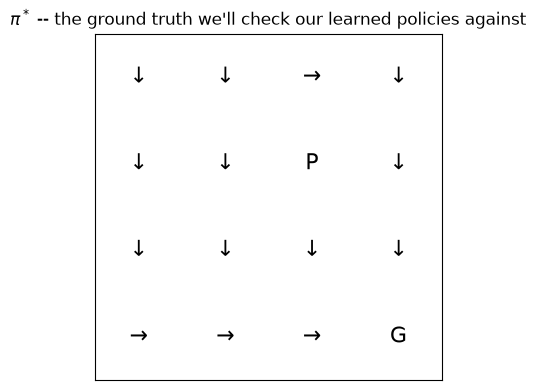

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

np.random.seed(0)

class GridWorld:
    """Same GridWorld as notebooks 1-2, kept self-contained here."""

    ACTIONS = ["up", "down", "left", "right"]
    ACTION_DELTAS = {
        "up": (-1, 0), "down": (1, 0), "left": (0, -1), "right": (0, 1),
    }
    ARROWS = {"up": "↑", "down": "↓", "left": "←", "right": "→"}

    def __init__(self, height=4, width=4, start=(0, 0), goal=(3, 3), pit=(1, 2),
                 step_reward=-1.0, goal_reward=10.0, pit_reward=-10.0, gamma=0.95):
        self.height, self.width = height, width
        self.start, self.goal, self.pit = start, goal, pit
        self.step_reward, self.goal_reward, self.pit_reward = step_reward, goal_reward, pit_reward
        self.gamma = gamma
        self.all_states = [(r, c) for r in range(height) for c in range(width)]

    def is_terminal(self, rc):
        return rc == self.goal or rc == self.pit

    def step(self, rc, action):
        if self.is_terminal(rc):
            raise ValueError("Cannot step from a terminal state.")
        dr, dc = self.ACTION_DELTAS[action]
        r, c = rc[0] + dr, rc[1] + dc
        if not (0 <= r < self.height and 0 <= c < self.width):
            r, c = rc
        next_rc = (r, c)
        if next_rc == self.goal:
            reward = self.goal_reward
        elif next_rc == self.pit:
            reward = self.pit_reward
        else:
            reward = self.step_reward
        return next_rc, reward, self.is_terminal(next_rc)

env = GridWorld()

def plot_value_grid(env, V, title, ax=None):
    grid = np.array([[V.get((r, c), 0.0) for c in range(env.width)] for r in range(env.height)])
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(4.5, 4.5))
    im = ax.imshow(grid, cmap="RdYlGn")
    for r in range(env.height):
        for c in range(env.width):
            ax.text(c, r, f"{grid[r,c]:.1f}", ha="center", va="center")
    ax.set_title(title)
    if own_fig:
        plt.colorbar(im)
        plt.show()

def plot_policy_grid(env, policy_probs, title, ax=None):
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(4.5, 4.5))
    ax.imshow(np.zeros((env.height, env.width)), cmap="Greys", vmin=0, vmax=1)
    for r in range(env.height):
        for c in range(env.width):
            s = (r, c)
            if s == env.goal:
                label = "G"
            elif s == env.pit:
                label = "P"
            else:
                best_a = max(policy_probs[s], key=policy_probs[s].get)
                label = GridWorld.ARROWS[best_a]
            ax.text(c, r, label, ha="center", va="center", fontsize=16)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title)
    if own_fig:
        plt.show()

# --- Ground truth from notebook 2, recomputed here for self-containment ---

def build_bellman_system(env, policy_probs):
    idx_of = {s: i for i, s in enumerate(env.all_states)}
    n = len(env.all_states)
    P_pi = np.zeros((n, n))
    R_pi = np.zeros(n)
    for s in env.all_states:
        i = idx_of[s]
        if env.is_terminal(s):
            P_pi[i, i] = 1.0
            continue
        for a, p_a in policy_probs[s].items():
            if p_a == 0.0:
                continue
            s_next, reward, _ = env.step(s, a)
            j = idx_of[s_next]
            P_pi[i, j] += p_a
            R_pi[i] += p_a * reward
    return P_pi, R_pi

uniform_probs = {s: {a: 0.25 for a in GridWorld.ACTIONS} for s in env.all_states}
P_pi, R_pi = build_bellman_system(env, uniform_probs)
V_exact_random_policy = {
    s: v for s, v in zip(env.all_states,
                          np.linalg.solve(np.eye(len(env.all_states)) - env.gamma * P_pi, R_pi))
}

def compute_Q_from_V(env, V, gamma):
    Q = {}
    for s in env.all_states:
        if env.is_terminal(s):
            Q[s] = {a: 0.0 for a in GridWorld.ACTIONS}
            continue
        Q[s] = {}
        for a in GridWorld.ACTIONS:
            s_next, reward, _ = env.step(s, a)
            Q[s][a] = reward + gamma * V[s_next]
    return Q

def greedy_policy_from_Q(Q):
    return {s: {a: (1.0 if a == max(qv, key=qv.get) else 0.0) for a in qv} for s, qv in Q.items()}

def value_iteration(env, gamma, theta=1e-8, max_sweeps=10000):
    V = {s: 0.0 for s in env.all_states}
    for sweep in range(max_sweeps):
        delta = 0.0
        V_new = {}
        for s in env.all_states:
            if env.is_terminal(s):
                V_new[s] = 0.0
                continue
            q_values = [env.step(s, a)[1] + gamma * V[env.step(s, a)[0]] for a in GridWorld.ACTIONS]
            V_new[s] = max(q_values)
            delta = max(delta, abs(V_new[s] - V[s]))
        V = V_new
        if delta < theta:
            break
    Q = compute_Q_from_V(env, V, gamma)
    return V, greedy_policy_from_Q(Q), Q

V_star, pi_star, Q_star = value_iteration(env, env.gamma)
print("Ground truth (from notebook 2's value iteration) recomputed for this notebook.")
plot_policy_grid(env, pi_star, "$\\pi^*$ -- the ground truth we'll check our learned policies against")

def took_an_optimal_action(Q_learned, s, Q_star, tol=1e-6):
    """Many GridWorld states have Q*-TIES between two or more actions (several
    equally short paths to the goal) -- plain 'does the argmax string match
    pi_star's arbitrarily-tie-broken choice' would flag those as disagreements
    even when the learned action is genuinely optimal. Instead, check whether
    the learned greedy action's TRUE Q* value matches the best possible Q*
    value at that state, within floating-point tolerance."""
    learned_action = max(Q_learned[s], key=Q_learned[s].get)
    best_possible = max(Q_star[s].values())
    return abs(Q_star[s][learned_action] - best_possible) < tol



## 1. Monte Carlo prediction, properly

Notebook 1 already estimated $V^\pi(s)$ by simulation: run many episodes,
average the observed returns from each visit to $s$. That was correct but
naive — it stored every sample and averaged at the end. Let's turn it into a
proper **incremental** algorithm, which is how it's actually implemented (and
which sets up the exact same pattern we'll reuse for TD).

The running average of $N$ numbers $x_1, \dots, x_N$ can be written
recursively. If $\mu_{N-1}$ is the average of the first $N-1$ numbers,

$$
\mu_N = \mu_{N-1} + \frac{1}{N}\big(x_N - \mu_{N-1}\big)
$$

(Check it: $\mu_{N-1} + \frac{1}{N}(x_N - \mu_{N-1}) = \frac{(N-1)\mu_{N-1} +
x_N}{N}$, which is exactly the definition of an average of $N$ numbers.) Apply
this to our problem, where each "sample" is a Monte Carlo return $G$ observed
after visiting state $s$:

$$
V(s) \leftarrow V(s) + \alpha \big( G - V(s) \big), \qquad \alpha = \tfrac{1}{N(s)}
$$

**This is worth staring at.** $\big(G - V(s)\big)$ is a **prediction error**:
how wrong was our current estimate, compared to what we just observed? The
update nudges $V(s)$ toward $G$ by a fraction $\alpha$ of that error. With
$\alpha = 1/N(s)$ this is mathematically identical to a plain running average.
But nothing stops us from using a small *constant* $\alpha$ instead — which no
longer computes an exact average (it exponentially downweights old data), but
is useful when the environment (or policy) is non-stationary and old data
should matter less. This "current estimate + learning-rate times error" shape
is the single most common update pattern in all of RL — you'll see the
identical shape again for TD, for SARSA, for Q-learning, and (in spirit) for
the gradient-based updates of every policy-gradient method later in this
course.

We use **first-visit MC**: only the *first* time $s$ is visited within an
episode counts toward its update, which keeps the samples closer to
independent (a state visited twice in one episode gives highly correlated
returns).


Mean |V_MC - V_exact| over all states: 2.1787


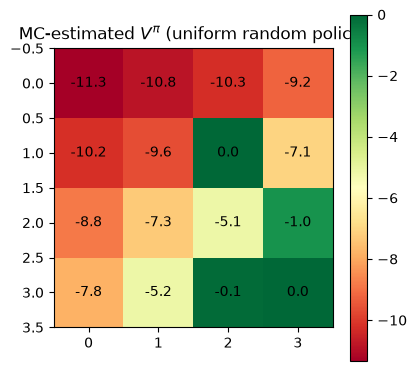

In [2]:

def uniform_random_policy(s):
    return np.random.choice(GridWorld.ACTIONS)

def generate_episode(env, policy_fn, max_steps=50):
    s = env.start
    episode = []
    for _ in range(max_steps):
        a = policy_fn(s)
        s_next, r, done = env.step(s, a)
        episode.append((s, a, r))
        s = s_next
        if done:
            break
    return episode

def mc_prediction(env, policy_fn, gamma, n_episodes=8000, max_steps=50):
    V = {s: 0.0 for s in env.all_states}
    N = {s: 0 for s in env.all_states}
    for _ in range(n_episodes):
        episode = generate_episode(env, policy_fn, max_steps)
        G = 0.0
        visited = set()
        for t in reversed(range(len(episode))):
            s_t, a_t, r_t = episode[t]
            G = r_t + gamma * G
            if s_t not in visited:          # first-visit
                visited.add(s_t)
                N[s_t] += 1
                V[s_t] += (1.0 / N[s_t]) * (G - V[s_t])   # the incremental-mean update
    return V

V_mc = mc_prediction(env, uniform_random_policy, env.gamma, n_episodes=8000)
mean_abs_err = np.mean([abs(V_mc[s] - V_exact_random_policy[s]) for s in env.all_states])
print(f"Mean |V_MC - V_exact| over all states: {mean_abs_err:.4f}")
plot_value_grid(env, V_mc, "MC-estimated $V^\\pi$ (uniform random policy)")



## 2. Why greedy control fails without exploration

The natural next step is **control**: use Monte Carlo returns not to evaluate
a fixed policy, but to *find a good one* — exactly the "improve" half of
Generalized Policy Iteration from notebook 2. The obvious approach: estimate
$Q(s,a)$ by MC, then act greedily, $\pi(s) = \arg\max_a Q(s,a)$.

This breaks immediately. Suppose the agent's very first random episode
happens to never try action "left" from some state $s$. Then $Q(s,
\text{left})$ stays at its initial value forever — the agent never has a
reason to try it again once it starts acting greedily, no matter how good that
action might actually be. **Pure greedy control can get permanently stuck
having never explored most of the state-action space.** This is the
*exploration-exploitation* problem, and it's a genuinely new issue that never
came up in notebook 2 — DP swept over *every* state-action pair by
construction, so it never needed to "choose" what to explore.

### Epsilon-greedy: a minimal fix

Instead of being purely greedy, act greedily most of the time but take a
uniformly random action with small probability $\epsilon$:

$$
\pi(a\mid s) = \begin{cases} 1 - \epsilon + \epsilon / |\mathcal{A}| & a = \arg\max_{a'} Q(s,a') \\ \epsilon / |\mathcal{A}| & \text{otherwise} \end{cases}
$$

This guarantees every action keeps getting tried, forever, with some nonzero
probability. It turns out the Policy Improvement Theorem from notebook 2 still
applies, with a small modification: greedifying *within the family of
$\epsilon$-soft policies* (rather than all the way to fully deterministic) is
still guaranteed to never make things worse. Intuitively: we've just shrunk the
space of "policies we're allowed to choose from" to those that still explore
a little, and improvement still works inside that restricted space by the same
unrolling argument as before.

Of course, an $\epsilon$-soft policy can never be exactly optimal ($\pi^*$ is
deterministic in every MDP we've considered). The standard fix is **GLIE**
("Greedy in the Limit with Infinite Exploration"): decay $\epsilon$ toward $0$
over training (e.g. $\epsilon_k = 1/k$), slowly enough that every state-action
pair is still visited infinitely often along the way, but ending up arbitrarily
close to purely greedy. Under GLIE, Monte Carlo control provably converges to
the true optimal $Q^*, \pi^*$.


MC control's greedy action is TRULY optimal (matches Q*, ties counted as correct) at 14/14 non-terminal states.


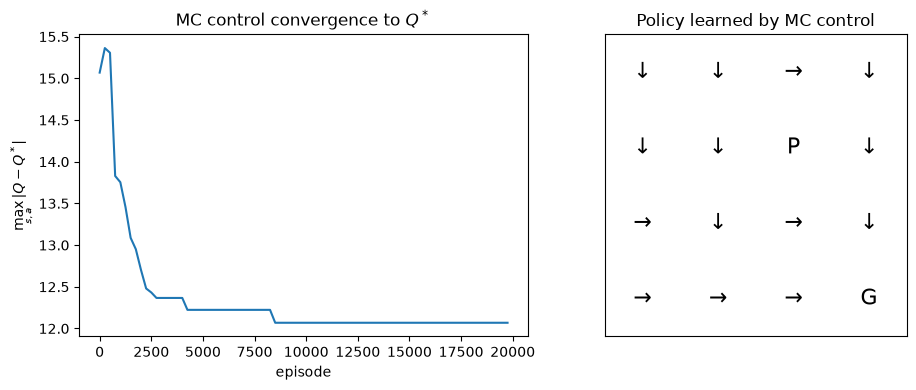

In [3]:

def epsilon_greedy_action(Q_s, epsilon, actions):
    if np.random.rand() < epsilon:
        return np.random.choice(actions)
    return max(Q_s, key=Q_s.get)

def mc_control(env, gamma, n_episodes=20000, epsilon_min=0.05, decay=1500, max_steps=100,
               eval_every=250, Q_star_ref=None):
    Q = {s: {a: 0.0 for a in GridWorld.ACTIONS} for s in env.all_states}
    N = {s: {a: 0 for a in GridWorld.ACTIONS} for s in env.all_states}
    error_history = []
    for ep in range(n_episodes):
        epsilon = max(epsilon_min, 1.0 / (1.0 + ep / decay))   # GLIE decay
        s = env.start
        episode = []
        for _ in range(max_steps):
            a = epsilon_greedy_action(Q[s], epsilon, GridWorld.ACTIONS)
            s_next, r, done = env.step(s, a)
            episode.append((s, a, r))
            s = s_next
            if done:
                break
        G = 0.0
        visited = set()
        for t in reversed(range(len(episode))):
            s_t, a_t, r_t = episode[t]
            G = r_t + gamma * G
            if (s_t, a_t) not in visited:
                visited.add((s_t, a_t))
                N[s_t][a_t] += 1
                Q[s_t][a_t] += (1.0 / N[s_t][a_t]) * (G - Q[s_t][a_t])
        if Q_star_ref is not None and ep % eval_every == 0:
            err = max(abs(Q[s][a] - Q_star_ref[s][a]) for s in env.all_states for a in GridWorld.ACTIONS)
            error_history.append((ep, err))
    return Q, error_history

Q_mc_control, mc_error_history = mc_control(env, env.gamma, Q_star_ref=Q_star)
pi_mc_control = greedy_policy_from_Q(Q_mc_control)

total = sum(1 for s in env.all_states if not env.is_terminal(s))
optimal = sum(took_an_optimal_action(Q_mc_control, s, Q_star) for s in env.all_states if not env.is_terminal(s))
print(f"MC control's greedy action is TRULY optimal (matches Q*, ties counted as correct) "
      f"at {optimal}/{total} non-terminal states.")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
eps_x, eps_y = zip(*mc_error_history)
axes[0].plot(eps_x, eps_y)
axes[0].set_xlabel("episode"); axes[0].set_ylabel(r"$\max_{s,a}|Q - Q^*|$")
axes[0].set_title("MC control convergence to $Q^*$")
plot_policy_grid(env, pi_mc_control, "Policy learned by MC control", ax=axes[1])
plt.tight_layout()
plt.show()



## 3. The trouble with Monte Carlo

MC control works, but it has two real weaknesses, both visible in the code
above:

1. **You must wait for the episode to end** before any update happens at all
   (`G` is only computable once the full trajectory is known). For long
   episodes — or *continuing* tasks that never terminate — this is a serious
   problem: no learning signal until a (possibly very distant) termination.
2. **High variance.** $G$ is the sum of *every* random reward along an entire
   random trajectory. Each individual return is a noisy sample of a quantity
   that depends on a long chain of random actions and (in general) random
   transitions.

Both problems have the same root cause: MC insists on using the *actual, fully
realized* return. What if, instead, we only looked one step ahead, and used
our own *current estimate* to stand in for everything after that?



## 4. Temporal-Difference learning: bootstrapping, derived

Go back to the Bellman equation from notebook 1:

$$
V^\pi(s) = \mathbb{E}\big[ r_{t+1} + \gamma V^\pi(s_{t+1}) \mid s_t = s \big]
$$

Monte Carlo estimates $V^\pi(s)$ by sampling the *entire* future and summing
it up ($G_t$ realized in full). TD-learning instead takes this equation
completely literally: it replaces the expectation with a **single sampled
transition** $(r_{t+1}, s_{t+1})$, and instead of also sampling everything
*after* $s_{t+1}$, it just plugs in the **current estimate** $V(s_{t+1})$ for
"everything after this point." This gives the TD(0) update:

$$
V(s_t) \leftarrow V(s_t) + \alpha \Big( \underbrace{r_{t+1} + \gamma V(s_{t+1})}_{\text{TD target}} - V(s_t) \Big)
$$

Compare directly to the MC update from Section 1 — same shape, $V(s)
\leftarrow V(s) + \alpha(\text{target} - V(s))$, just a different target:

| | target used |
|---|---|
| Monte Carlo | $G_t$ (the full, realized, sampled return) |
| TD(0) | $r_{t+1} + \gamma V(s_{t+1})$ (one real reward + a *bootstrapped* guess) |

The quantity $\delta_t = r_{t+1} + \gamma V(s_{t+1}) - V(s_t)$ is called the
**TD error**. It's a genuinely useful concept beyond the update rule itself:
it's a *moment-by-moment* measure of surprise — "how much did this single step
violate what I currently believe about the world?" (This same quantity, under
the name "reward prediction error," is also the leading computational model of
what dopamine neurons encode in animal brains — a nice, if informal,
connection between this 1980s RL idea and neuroscience.)

**Using bootstrapping means TD can update after every single step**, without
waiting for the episode to end — directly fixing MC's first weakness. It also
only depends on one random reward (not an entire trajectory of them), which
tends to make it lower variance — though, as we're about to see, not for free.


Mean |V_TD - V_exact| over all states: 0.5822


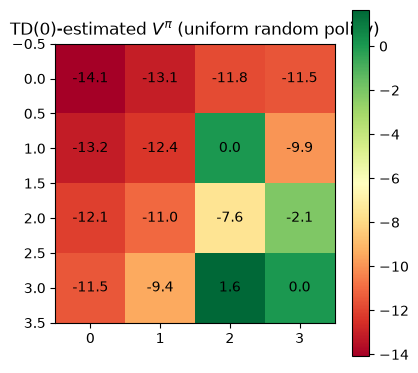

In [4]:

def td0_prediction(env, policy_fn, gamma, alpha=0.1, n_episodes=8000, max_steps=50):
    V = {s: 0.0 for s in env.all_states}
    for _ in range(n_episodes):
        s = env.start
        for _ in range(max_steps):
            a = policy_fn(s)
            s_next, r, done = env.step(s, a)
            target = r if done else r + gamma * V[s_next]
            V[s] += alpha * (target - V[s])
            s = s_next
            if done:
                break
    return V

V_td = td0_prediction(env, uniform_random_policy, env.gamma)
mean_abs_err_td = np.mean([abs(V_td[s] - V_exact_random_policy[s]) for s in env.all_states])
print(f"Mean |V_TD - V_exact| over all states: {mean_abs_err_td:.4f}")
plot_value_grid(env, V_td, "TD(0)-estimated $V^\\pi$ (uniform random policy)")


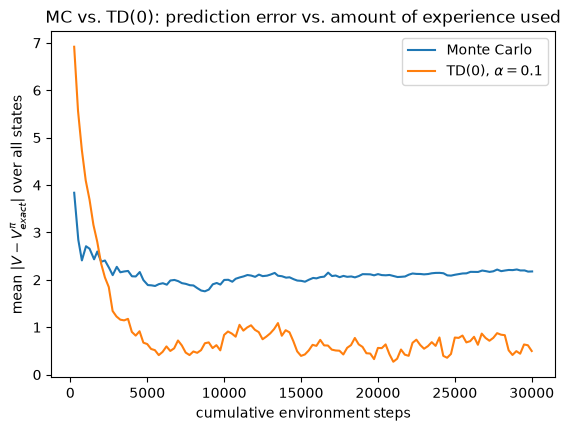

In [5]:

# Fair head-to-head: track error against the NUMBER OF ENVIRONMENT STEPS used
# so far, not episodes -- TD updates every step, MC only at episode ends, so
# comparing by episode count would be an apples-to-oranges comparison.

def run_prediction_experiment(env, policy_fn, gamma, V_true, method, alpha=0.1,
                               total_steps=30000, max_steps_per_episode=50, checkpoint_every=250):
    V = {s: 0.0 for s in env.all_states}
    N = {s: 0 for s in env.all_states}
    cumulative_steps = 0
    next_checkpoint = checkpoint_every
    checkpoints = []

    def record():
        err = np.mean([abs(V[s] - V_true[s]) for s in env.all_states])
        checkpoints.append((cumulative_steps, err))

    while cumulative_steps < total_steps:
        s = env.start
        episode = []
        for _ in range(max_steps_per_episode):
            a = policy_fn(s)
            s_next, r, done = env.step(s, a)
            if method == "td":
                target = r if done else r + gamma * V[s_next]
                V[s] += alpha * (target - V[s])
            episode.append((s, a, r))
            s = s_next
            cumulative_steps += 1
            if method == "td" and cumulative_steps >= next_checkpoint:
                record(); next_checkpoint += checkpoint_every
            if done:
                break
        if method == "mc":
            G = 0.0
            visited = set()
            for t in reversed(range(len(episode))):
                s_t, a_t, r_t = episode[t]
                G = r_t + gamma * G
                if s_t not in visited:
                    visited.add(s_t)
                    N[s_t] += 1
                    V[s_t] += (1.0 / N[s_t]) * (G - V[s_t])
            if cumulative_steps >= next_checkpoint:
                record(); next_checkpoint += checkpoint_every
    return V, checkpoints

np.random.seed(1)
_, mc_curve = run_prediction_experiment(env, uniform_random_policy, env.gamma, V_exact_random_policy, method="mc")
np.random.seed(1)
_, td_curve = run_prediction_experiment(env, uniform_random_policy, env.gamma, V_exact_random_policy, method="td", alpha=0.1)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(*zip(*mc_curve), label="Monte Carlo")
ax.plot(*zip(*td_curve), label="TD(0), $\\alpha=0.1$")
ax.set_xlabel("cumulative environment steps")
ax.set_ylabel("mean $|V - V^\\pi_{exact}|$ over all states")
ax.set_title("MC vs. TD(0): prediction error vs. amount of experience used")
ax.legend()
plt.show()



## 5. Bias, variance, and the space in between

Take the comparison in the plot above at face value and ask *why*:

- **MC is unbiased**: $\mathbb{E}[G_t] = V^\pi(s_t)$ by definition — averaging
  infinitely many MC samples converges to the exactly correct value, no matter
  how it's initialized. But each individual $G_t$ has high variance, since it
  depends on an entire random trajectory's worth of randomness.
- **TD(0) is biased** (at least early in training): its target,
  $r_{t+1}+\gamma V(s_{t+1})$, uses $V(s_{t+1})$, which itself starts out
  *wrong* (we initialized everything to 0!). Early TD updates are chasing a
  target that's partly wrong. But that target only depends on *one* random
  transition, so it has much lower variance than a full Monte Carlo return —
  which is usually a good trade in practice, and is exactly why the TD curve
  above tends to make faster early progress per unit of experience.

**Is there something in between "bootstrap after exactly 1 step" (TD) and
"bootstrap after the entire episode" (MC)?** Yes — look one step further into
the future before bootstrapping. The **n-step return** is:

$$
G_t^{(n)} = r_{t+1} + \gamma r_{t+2} + \dots + \gamma^{n-1} r_{t+n} + \gamma^n V(s_{t+n})
$$

Note $G_t^{(1)}$ is exactly the TD(0) target, and $G_t^{(n)}$ as $n \to \infty$
(or $n$ reaches the episode length) recovers the full Monte Carlo return. Every
value of $n$ in between is a different point on the bias-variance dial: bigger
$n$ means more real, sampled reward (less bias from a possibly-wrong $V$, more
variance from more randomness); smaller $n$ means more bootstrapping (more
bias, less variance).

(One more step beyond what we implement here, for the curious: instead of
picking one fixed $n$, you can average *all* n-step returns together with
exponentially decaying weights $(1-\lambda)\lambda^{n-1}$ — this is the
**$\lambda$-return**, and using it in place of $G_t^{(n)}$ gives **TD($\lambda$)**.
Computing every $n$-step return directly would be expensive; the standard
trick is *eligibility traces*, a clever bookkeeping device that gets the exact
same update with $O(1)$ extra computation per step. We leave a full
implementation as an exercise — the important conceptual point is just that
$\lambda$ is a single dial that smoothly interpolates between TD(0)
($\lambda=0$) and Monte Carlo ($\lambda=1$).)


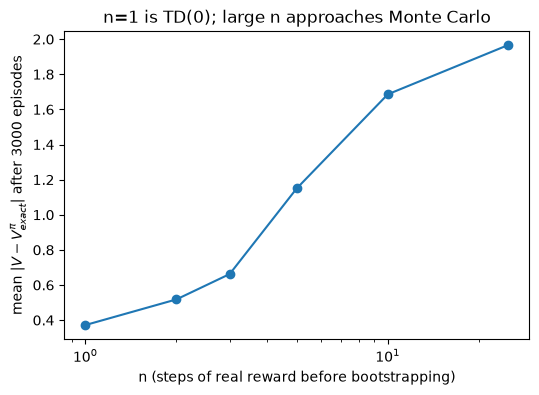

n=1 (pure TD) result: 0.37194656643146307
n=25 (close to full-episode MC, since episodes rarely exceed ~25 steps here) result: 1.966313972449073


In [6]:

def nstep_td_prediction(env, policy_fn, gamma, n, alpha=0.1, n_episodes=4000, max_steps=50):
    """Standard n-step TD prediction (Sutton & Barto, Sec. 7.1), using a
    sliding window of the last n rewards/states instead of full eligibility
    traces -- simple and transparent, at the cost of a little more bookkeeping
    than the (mathematically equivalent) trace-based implementation."""
    V = {s: 0.0 for s in env.all_states}
    for _ in range(n_episodes):
        states = [env.start]
        rewards = [0.0]  # rewards[0] is an unused placeholder, matching 1-indexed reward convention
        T = float("inf")
        t = 0
        s = env.start
        while True:
            if t < T:
                a = policy_fn(s)
                s_next, r, done = env.step(s, a)
                states.append(s_next)
                rewards.append(r)
                if done:
                    T = t + 1
                s = s_next
            tau = t - n + 1
            if tau >= 0:
                hi = min(tau + n, T)
                G = sum(gamma ** (i - tau - 1) * rewards[i] for i in range(tau + 1, hi + 1))
                if tau + n < T:
                    G += gamma ** n * V[states[tau + n]]
                s_tau = states[tau]
                V[s_tau] += alpha * (G - V[s_tau])
            if tau == T - 1:
                break
            t += 1
    return V

n_values = [1, 2, 3, 5, 10, 25]
errors_by_n = []
for n in n_values:
    np.random.seed(2)
    V_n = nstep_td_prediction(env, uniform_random_policy, env.gamma, n=n, alpha=0.1, n_episodes=3000)
    err = np.mean([abs(V_n[s] - V_exact_random_policy[s]) for s in env.all_states])
    errors_by_n.append(err)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(n_values, errors_by_n, marker="o")
ax.set_xlabel("n (steps of real reward before bootstrapping)")
ax.set_ylabel("mean $|V - V^\\pi_{exact}|$ after 3000 episodes")
ax.set_title("n=1 is TD(0); large n approaches Monte Carlo")
ax.set_xscale("log")
plt.show()
print("n=1 (pure TD) result:", errors_by_n[0])
print("n=25 (close to full-episode MC, since episodes rarely exceed ~25 steps here) result:", errors_by_n[-1])



## 6. On-policy TD control: SARSA

Just as MC control applied the MC prediction idea to $Q$ instead of $V$ (with
$\epsilon$-greedy exploration bolted on), we can apply the *TD* idea to $Q$:

$$
Q(s_t,a_t) \leftarrow Q(s_t,a_t) + \alpha\Big(r_{t+1} + \gamma\, Q(s_{t+1}, a_{t+1}) - Q(s_t,a_t)\Big)
$$

The name **SARSA** literally spells out the five quantities the update needs:
$(S_t, A_t, R_{t+1}, S_{t+1}, A_{t+1})$. Crucially, $a_{t+1}$ here is the
action the agent's *actual* current ($\epsilon$-greedy) policy would take next
— **not necessarily the best possible action**. This makes SARSA
**on-policy**: it learns the value of the policy it is *actually following*
(exploration noise and all), not of some other, different policy. We'll see
exactly why that distinction matters in Section 8.


SARSA's greedy action is TRULY optimal at 13/14 non-terminal states.


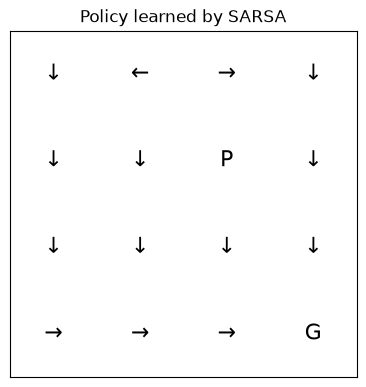

In [7]:

def sarsa(env, gamma, alpha=0.1, n_episodes=8000, epsilon_min=0.05, decay=1500, max_steps=100):
    Q = {s: {a: 0.0 for a in GridWorld.ACTIONS} for s in env.all_states}
    for ep in range(n_episodes):
        epsilon = max(epsilon_min, 1.0 / (1.0 + ep / decay))
        s = env.start
        a = epsilon_greedy_action(Q[s], epsilon, GridWorld.ACTIONS)
        for _ in range(max_steps):
            s_next, r, done = env.step(s, a)
            if done:
                target = r
            else:
                a_next = epsilon_greedy_action(Q[s_next], epsilon, GridWorld.ACTIONS)
                target = r + gamma * Q[s_next][a_next]
            Q[s][a] += alpha * (target - Q[s][a])
            if done:
                break
            s, a = s_next, a_next
    return Q

Q_sarsa = sarsa(env, env.gamma)
pi_sarsa = greedy_policy_from_Q(Q_sarsa)
optimal = sum(took_an_optimal_action(Q_sarsa, s, Q_star) for s in env.all_states if not env.is_terminal(s))
print(f"SARSA's greedy action is TRULY optimal at {optimal}/{total} non-terminal states.")
plot_policy_grid(env, pi_sarsa, "Policy learned by SARSA")



## 7. Off-policy TD control: Q-learning

Change exactly one thing in the SARSA update: instead of plugging in the value
of whatever action the current policy *actually* takes next, plug in the value
of the **best possible** next action:

$$
Q(s_t,a_t) \leftarrow Q(s_t,a_t) + \alpha\Big(r_{t+1} + \gamma\, \max_{a'} Q(s_{t+1}, a') - Q(s_t,a_t)\Big)
$$

This is **Q-learning**. The target no longer depends on what the agent
actually does next (that's still $\epsilon$-greedy, for exploration) — it
directly targets $Q^*$, the value of the *optimal* policy, regardless of the
exploratory detours the agent is currently taking to gather data.

This is the crucial distinction: **Q-learning is off-policy** — it learns
about one policy (the greedy/optimal one, the "target policy") while following
a *different* policy (epsilon-greedy, the "behavior policy") to generate data.
SARSA is **on-policy** — target policy and behavior policy are the same thing.
Keep this exact distinction in your head; it resurfaces explicitly in notebook
6, where PPO needs an importance-sampling correction *because* the policy used
to generate rollouts has drifted slightly off-policy from the one currently
being updated.


Q-learning's greedy action is TRULY optimal at 14/14 non-terminal states.


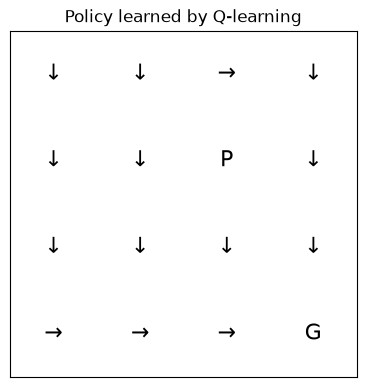


On this GridWorld, SARSA and Q-learning both essentially find the optimal policy --
the on-policy/off-policy difference is real but SUBTLE here, because our
epsilon decays to near-zero, so the two policies end up almost identical
by the time training ends. (Note: several GridWorld states have exact Q*
TIES between two or more actions -- multiple equally-short paths to the
goal -- so we check against the true optimal Q*-VALUE, not a single
arbitrarily tie-broken reference action.) Section 8 uses an environment
specifically designed to make the on-policy/off-policy difference dramatic
and impossible to miss.


In [8]:

def q_learning(env, gamma, alpha=0.1, n_episodes=8000, epsilon_min=0.05, decay=1500, max_steps=100):
    Q = {s: {a: 0.0 for a in GridWorld.ACTIONS} for s in env.all_states}
    for ep in range(n_episodes):
        epsilon = max(epsilon_min, 1.0 / (1.0 + ep / decay))
        s = env.start
        for _ in range(max_steps):
            a = epsilon_greedy_action(Q[s], epsilon, GridWorld.ACTIONS)
            s_next, r, done = env.step(s, a)
            target = r if done else r + gamma * max(Q[s_next].values())
            Q[s][a] += alpha * (target - Q[s][a])
            s = s_next
            if done:
                break
    return Q

Q_qlearn = q_learning(env, env.gamma)
pi_qlearn = greedy_policy_from_Q(Q_qlearn)
optimal = sum(took_an_optimal_action(Q_qlearn, s, Q_star) for s in env.all_states if not env.is_terminal(s))
print(f"Q-learning's greedy action is TRULY optimal at {optimal}/{total} non-terminal states.")
plot_policy_grid(env, pi_qlearn, "Policy learned by Q-learning")
print("\nOn this GridWorld, SARSA and Q-learning both essentially find the optimal policy --")
print("the on-policy/off-policy difference is real but SUBTLE here, because our")
print("epsilon decays to near-zero, so the two policies end up almost identical")
print("by the time training ends. (Note: several GridWorld states have exact Q*")
print("TIES between two or more actions -- multiple equally-short paths to the")
print("goal -- so we check against the true optimal Q*-VALUE, not a single")
print("arbitrarily tie-broken reference action.) Section 8 uses an environment")
print("specifically designed to make the on-policy/off-policy difference dramatic")
print("and impossible to miss.")



## 8. Making the difference impossible to miss: Cliff Walking

Here's the classic experiment (Sutton & Barto, Example 6.6) that makes the
on-policy vs. off-policy distinction concrete. The environment: a long, thin
grid. The bottom row, between start and goal, is a "cliff" — stepping into it
gives a huge penalty and sends the agent straight back to the start (the
episode does **not** end, so the agent keeps accumulating this penalty every
time it falls in). Every other step costs $-1$, same as before.

Crucially, we'll train with a **constant** $\epsilon$ (no GLIE decay this
time). That's what makes the effect visible: the agent's exploratory noise
never goes away, so a policy that only looks good "if you ignore the
occasional random slip" is actually a worse policy to be following *during
training*, and SARSA — which evaluates the policy it is actually running,
slips included — is able to notice that.

**Prediction before we run it:** Q-learning's target always assumes the *best*
next action will be taken, so it will happily learn the shortest path — which
runs directly along the edge of the cliff — because it evaluates that path
assuming no more exploration mistakes happen. SARSA's target uses the action
its own $\epsilon$-greedy policy will actually take, which occasionally
(randomly) means falling off — so SARSA learns to route further away from the
cliff, trading a few extra steps for a much lower chance of an accidental
$-100$.


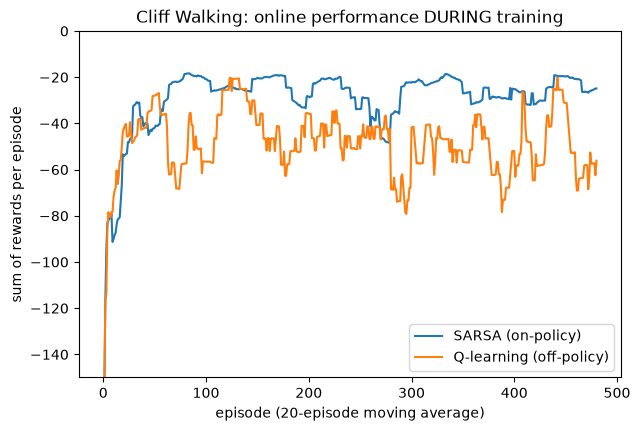

In [9]:

class CliffWalking:
    ACTIONS = GridWorld.ACTIONS
    ACTION_DELTAS = GridWorld.ACTION_DELTAS

    def __init__(self, height=4, width=12, gamma=1.0):
        self.height, self.width = height, width
        self.start = (height - 1, 0)
        self.goal = (height - 1, width - 1)
        self.cliff = {(height - 1, c) for c in range(1, width - 1)}
        self.gamma = gamma
        self.all_states = [(r, c) for r in range(height) for c in range(width)]

    def is_terminal(self, rc):
        return rc == self.goal

    def step(self, rc, action):
        dr, dc = self.ACTION_DELTAS[action]
        r, c = rc[0] + dr, rc[1] + dc
        if not (0 <= r < self.height and 0 <= c < self.width):
            r, c = rc
        next_rc = (r, c)
        if next_rc in self.cliff:
            return self.start, -100.0, False
        if next_rc == self.goal:
            return next_rc, -1.0, True
        return next_rc, -1.0, False

cliff_env = CliffWalking()

def sarsa_track(env, gamma, alpha, epsilon, n_episodes, max_steps=200):
    Q = {s: {a: 0.0 for a in env.ACTIONS} for s in env.all_states}
    rewards = []
    for ep in range(n_episodes):
        s = env.start
        a = epsilon_greedy_action(Q[s], epsilon, env.ACTIONS)
        total_r = 0.0
        for _ in range(max_steps):
            s_next, r, done = env.step(s, a)
            total_r += r
            if done:
                target = r
            else:
                a_next = epsilon_greedy_action(Q[s_next], epsilon, env.ACTIONS)
                target = r + gamma * Q[s_next][a_next]
            Q[s][a] += alpha * (target - Q[s][a])
            if done:
                break
            s, a = s_next, a_next
        rewards.append(total_r)
    return Q, rewards

def q_learning_track(env, gamma, alpha, epsilon, n_episodes, max_steps=200):
    Q = {s: {a: 0.0 for a in env.ACTIONS} for s in env.all_states}
    rewards = []
    for ep in range(n_episodes):
        s = env.start
        total_r = 0.0
        for _ in range(max_steps):
            a = epsilon_greedy_action(Q[s], epsilon, env.ACTIONS)
            s_next, r, done = env.step(s, a)
            total_r += r
            target = r if done else r + gamma * max(Q[s_next].values())
            Q[s][a] += alpha * (target - Q[s][a])
            s = s_next
            if done:
                break
        rewards.append(total_r)
    return Q, rewards

np.random.seed(3)
Q_sarsa_cliff, sarsa_rewards = sarsa_track(cliff_env, gamma=1.0, alpha=0.5, epsilon=0.1, n_episodes=500)
np.random.seed(3)
Q_qlearn_cliff, qlearn_rewards = q_learning_track(cliff_env, gamma=1.0, alpha=0.5, epsilon=0.1, n_episodes=500)

def moving_average(x, window=20):
    x = np.array(x)
    return np.convolve(x, np.ones(window) / window, mode="valid")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(moving_average(sarsa_rewards), label="SARSA (on-policy)")
ax.plot(moving_average(qlearn_rewards), label="Q-learning (off-policy)")
ax.set_ylim(-150, 0)
ax.set_xlabel("episode (20-episode moving average)")
ax.set_ylabel("sum of rewards per episode")
ax.set_title("Cliff Walking: online performance DURING training")
ax.legend()
plt.show()


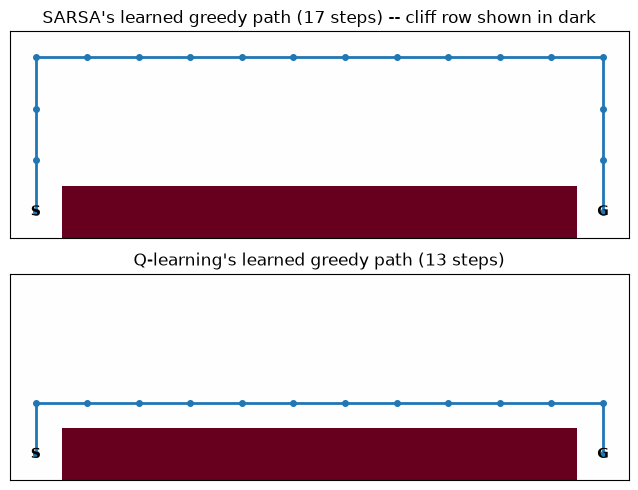

SARSA path length: 17 steps, steps spent hugging the cliff edge: 0
Q-learning path length: 13 steps, steps spent hugging the cliff edge: 10


In [10]:

def greedy_rollout(env, Q, max_steps=100):
    s = env.start
    path = [s]
    for _ in range(max_steps):
        a = max(Q[s], key=Q[s].get)
        s_next, r, done = env.step(s, a)
        if s_next == s:
            break   # stuck against a wall -- stop rather than loop forever
        path.append(s_next)
        s = s_next
        if done:
            break
    return path

def plot_cliff_path(env, path, title, ax):
    grid = np.zeros((env.height, env.width))
    for (r, c) in env.cliff:
        grid[r, c] = -1
    ax.imshow(grid, cmap="RdGy", vmin=-1, vmax=1)
    pr, pc = zip(*path)
    ax.plot(pc, pr, marker="o", color="tab:blue", linewidth=2, markersize=4)
    sr, sc = env.start; gr, gc = env.goal
    ax.text(sc, sr, "S", ha="center", va="center", fontweight="bold")
    ax.text(gc, gr, "G", ha="center", va="center", fontweight="bold")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title)

sarsa_path = greedy_rollout(cliff_env, Q_sarsa_cliff)
qlearn_path = greedy_rollout(cliff_env, Q_qlearn_cliff)

fig, axes = plt.subplots(2, 1, figsize=(9, 5))
plot_cliff_path(cliff_env, sarsa_path, f"SARSA's learned greedy path ({len(sarsa_path)-1} steps) -- cliff row shown in dark", axes[0])
plot_cliff_path(cliff_env, qlearn_path, f"Q-learning's learned greedy path ({len(qlearn_path)-1} steps)", axes[1])
plt.tight_layout()
plt.show()

def steps_along_cliff_edge(env, path):
    """Count steps spent in the row directly above the cliff, EXCLUDING the
    unavoidable single-step vertical transit at the start/goal columns --
    that isolates genuine cliff-hugging from just passing through on the way
    to/from a completely different route."""
    edge_row = env.height - 2
    return sum(1 for (r, c) in path if r == edge_row and 1 <= c <= env.width - 2)

print(f"SARSA path length: {len(sarsa_path)-1} steps, "
      f"steps spent hugging the cliff edge: {steps_along_cliff_edge(cliff_env, sarsa_path)}")
print(f"Q-learning path length: {len(qlearn_path)-1} steps, "
      f"steps spent hugging the cliff edge: {steps_along_cliff_edge(cliff_env, qlearn_path)}")



Look at both plots together. Q-learning's *greedy* (post-training,
exploration switched off) path is the short one, running right along the
cliff edge — it optimized assuming perfect play. SARSA's greedy path takes a
detour along the top, away from the cliff — because *during training*, its
on-policy updates had to account for its own $\epsilon$-greedy stumbling, and
routing near the cliff was genuinely costly under that stumbling. Look at the
learning-curve plot from the previous cell too: SARSA achieves a *better
(less negative) online reward while training* even though Q-learning's
*final, greedy* policy is objectively shorter — because Q-learning's
$\epsilon$-greedy *training* behavior kept accidentally walking off the cliff
it was learning to hug. This is the on-policy/off-policy distinction, made
impossible to hand-wave away.



## 9. Why this distinction matters for LLM RL

Keep two things from this notebook in mind as you move forward:

**Bootstrapping (TD) is exactly what a learned critic does.** Where TD(0)
computes $\delta_t = r_{t+1} + \gamma V(s_{t+1}) - V(s_t)$ with $V$ stored in a
table, actor-critic methods (notebook 5 onward, including the critic used
inside PPO for RLHF in notebook 7) compute the *identical* quantity with $V$
replaced by a neural network $V_\phi$, and train that network by gradient
descent on the squared TD error, $(V_\phi(s_t) - \text{target})^2$. Every
intuition you now have about TD's bias (a critic that hasn't learned yet gives
bad targets, which the policy update will follow anyway, at least for a
while) and its variance-reduction benefit relative to Monte Carlo transfers
directly. Notebook 4 makes this literal by using a neural network in place of
our tables for the first time.

**On-policy vs. off-policy is a spectrum the rest of this course lives on.**
SARSA (on-policy) and Q-learning (off-policy) are the cleanest possible
illustration of the distinction, but it reappears everywhere in LLM RL, phrased
differently each time:

- **PPO** (notebook 6-7) is nominally on-policy, but it performs several
  gradient updates per batch of rollouts, so by the last update the policy
  has already drifted a little from the one that *generated* the data —
  making it slightly off-policy in practice. It corrects for this with an
  **importance sampling** ratio $\pi_\theta(a|s)/\pi_{\text{old}}(a|s)$ (which
  you'll recognize immediately once we get there, as a direct generalization
  of the same "learn about one distribution while sampling from a slightly
  different one" idea underlying off-policy Q-learning).
- **RLOO and GRPO** (notebooks 8-9) are Monte-Carlo-flavored, strictly
  on-policy methods with *no bootstrapped critic at all* — they're much closer
  in spirit to this notebook's MC control than to TD/SARSA/Q-learning. Once
  you've felt, first-hand, the bias/variance and "must wait for the episode to
  end" tradeoffs of MC vs. TD in Sections 3-5, you'll immediately understand
  *why* dropping the critic in GRPO is a real, deliberate trade-off (simpler,
  unbiased, no critic to train — at the cost of the variance MC always pays),
  not just an arbitrary design choice.



## 10. Recap & exercises

**What we derived and implemented, from first principles:**

- The incremental-mean update rule, and first-visit MC prediction built from
  it.
- Why pure greedy control fails (insufficient exploration), $\epsilon$-greedy
  as a minimal fix, and GLIE as the condition needed for eventual convergence
  to the true optimum.
- TD(0), derived by sampling one step of the Bellman equation and bootstrapping
  off the current value estimate for the rest — with a head-to-head experiment
  against MC, measured fairly (error vs. environment steps used).
- The bias-variance tradeoff between MC and TD, and n-step TD as the explicit
  dial between them.
- SARSA (on-policy) and Q-learning (off-policy) TD control, and the Cliff
  Walking experiment that makes their difference concrete and visible rather
  than abstract.

### Exercises

1. **Expected SARSA.** Replace SARSA's target $Q(s',a')$ (the value of the
   action actually sampled next) with $\sum_{a'} \pi(a'|s')Q(s',a')$ (the
   *expected* value under the current $\epsilon$-greedy policy). This removes
   the extra variance from sampling $a'$ while remaining on-policy. Implement
   it and compare its Cliff Walking learning curve to SARSA and Q-learning.
2. **Alpha sensitivity.** Re-run the MC vs. TD comparison (Section 4) with
   `alpha` set to `0.01` and `0.5`. How does the tradeoff between
   convergence speed and final noise level in the TD curve change?
3. **Eligibility traces (stretch goal).** Implement TD($\lambda$) using
   eligibility traces instead of the explicit n-step sliding window used in
   Section 5, and confirm it produces (nearly) the same result as
   `nstep_td_prediction` for a comparable effective $n$.
4. **Bigger cliff.** Widen `CliffWalking` and re-run the SARSA/Q-learning
   comparison. Does the online-reward gap between the two widen or narrow?
   Why would the width of the cliff change how costly the difference between
   on-policy and off-policy learning is?
